1. Importar as bibliotecas

In [71]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

2. Definir a variável "arquivo" pelo nome da planilha.


In [72]:
arquivo='dados_projeto1.xlsx'


3. Ler a planilha no Python. Escolha um nome para armazenar. Escolheremos df

In [73]:
df=pd.read_excel(arquivo)
df

,Escolaridade,Sexo,Idade
0,superior,fem,21
1,superior,masc,28
2,fundamental,masc,13
3,médio,masc,19
4,médio,fem,19
5,superior,fem,27
6,fundamental,masc,16
7,médio,fem,23
8,fundamental,fem,15
9,superior,masc,23


**Gráficos para variáveis quantitativas e qualitativas**

In [74]:
#podemos escolher a priori o tamanho das fontes usando o comando a seguir
#Veja que está como comentário. Para utilizá-lo, retire o símbolo # e teste os valores
#plt.rcParams["figure.figsize"]=(10,10)

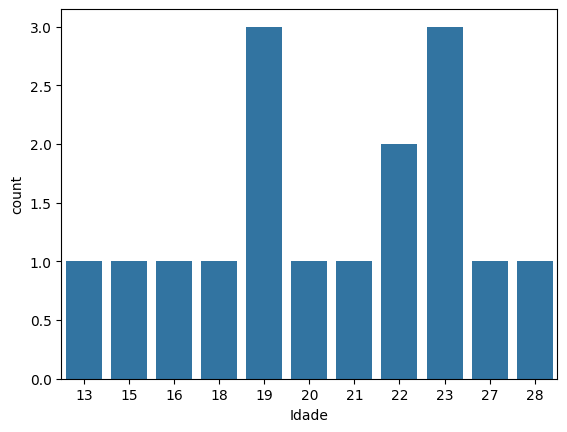

In [75]:
#gráfico de coluna - contando as frequências
sns.countplot(x='Idade',data=df)
plt.show()

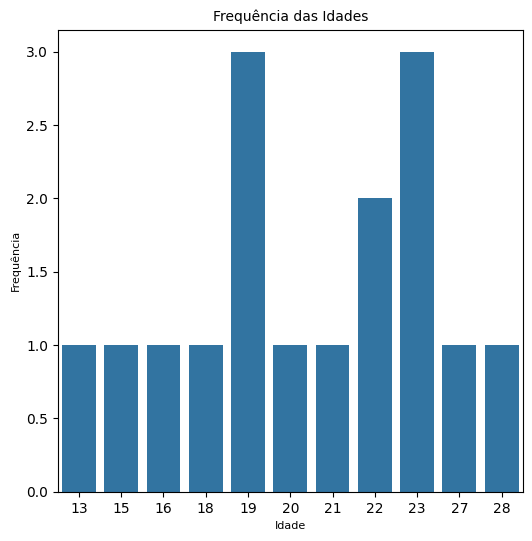

In [76]:
#ajustando os eixos da figura para melhor visualização e dando nomes aos eixos
fig,ax=plt.subplots(figsize=(6,6))
sns.countplot(x='Idade',data=df)
ax.set_xlabel("Idade", size=8)
ax.set_ylabel("Frequência",size=8)
ax.set_title("Frequência das Idades",size=10)
plt.show()


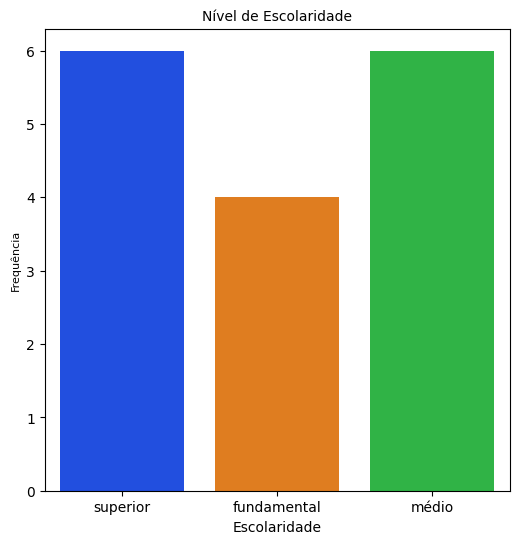

In [77]:

#gráficos de variável qualitativa
#só com o countplot ele não ordena

#ajustando os eixos da figura para melhor visualização e dando nomes aos eixos.
#ajustando cores
fig,ax=plt.subplots(figsize=(6,6))
sns.countplot(x='Escolaridade',data=df,hue='Escolaridade',palette='bright',legend=False)
ax.set_ylabel("Frequência",size=8)
ax.set_title("Nível de Escolaridade",size=10)
plt.show()

In [78]:
#gráficos de variável qualitativa ordenada
df2=df.Escolaridade.value_counts().sort_index()
df2


,count
Escolaridade,
fundamental,4
médio,6
superior,6


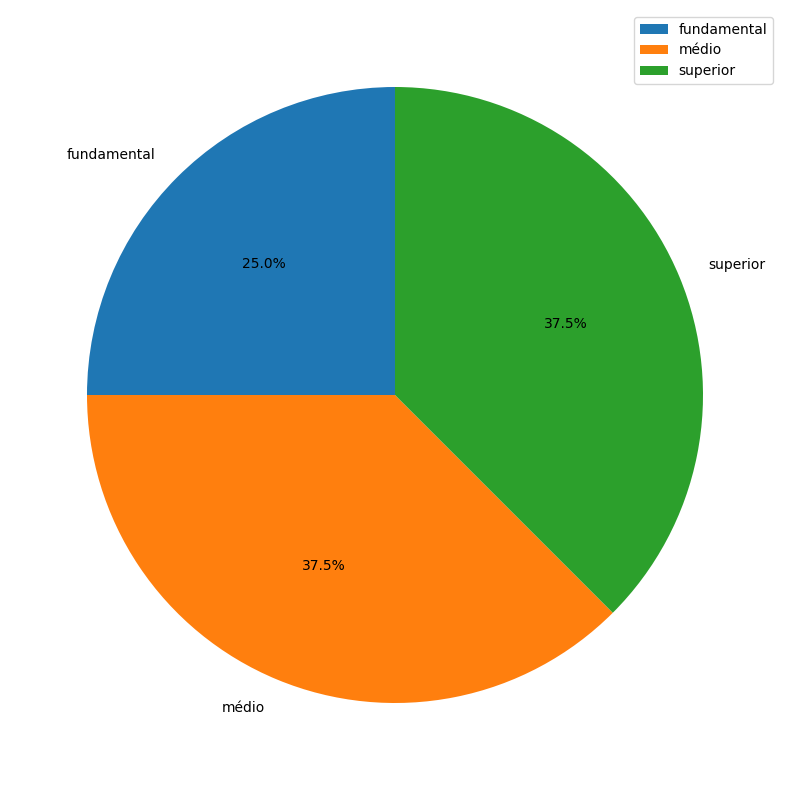

In [79]:
#criando os rótulos e os valores baseados na ordenação anterior
rótulos2=['fundamental', 'médio', 'superior']
valores2=[4,6,6]
#criando gráfico de setor
plt.figure(figsize=(10,10))
plt.pie(valores2,labels=rótulos2,autopct='%1.1f%%',startangle=90)
plt.legend()
plt.show()

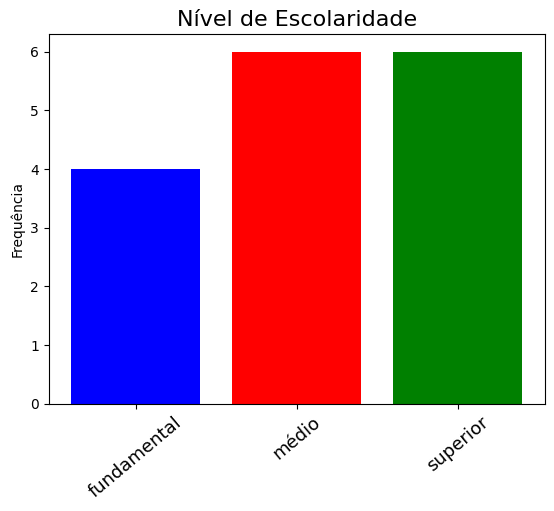

In [80]:
#gráfico de colunas, também usando os rótulos e valores. NESTE CASO ORDENADO POIS rótulos e valores SÃO AS LISTAS JÁ NA ORDEM QUE QUEREMOS.
#escolhendo cores
cores=['b','r','g']
plt.bar(rótulos2,valores2,color=cores)
plt.ylabel('Frequência',fontsize=10)
plt.xticks(rótulos2,fontsize=13,rotation=40)
plt.title('Nível de Escolaridade',fontsize=16)
plt.show()


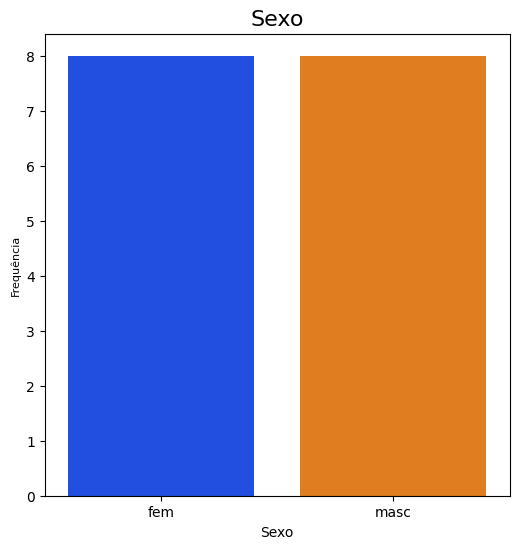

In [81]:
#gráficos de variável qualitativa Sexo (não precisa ordenar)
#ajustando os eixos da figura para melhor visualização e dando nomes aos eixos
fig,ax=plt.subplots(figsize=(6,6))
sns.countplot(x='Sexo',data=df, hue='Sexo',palette='bright',legend=False)
ax.set_ylabel("Frequência",size=8)
plt.title('Sexo',fontsize=16)
plt.show()

In [82]:
#para gráfico de setor precisamos contar antes
df3=df.Sexo.value_counts()
df3

,count
Sexo,
fem,8
masc,8


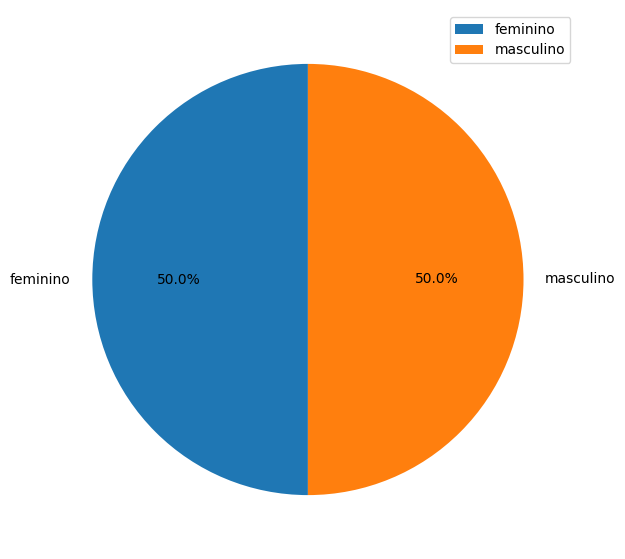

In [83]:
rótulos3=['feminino', 'masculino']
valores3=[8,8]
plt.figure(figsize=(7,7))
plt.pie(valores3,labels=rótulos3,autopct='%1.1f%%',startangle=90)
plt.legend()
plt.show()

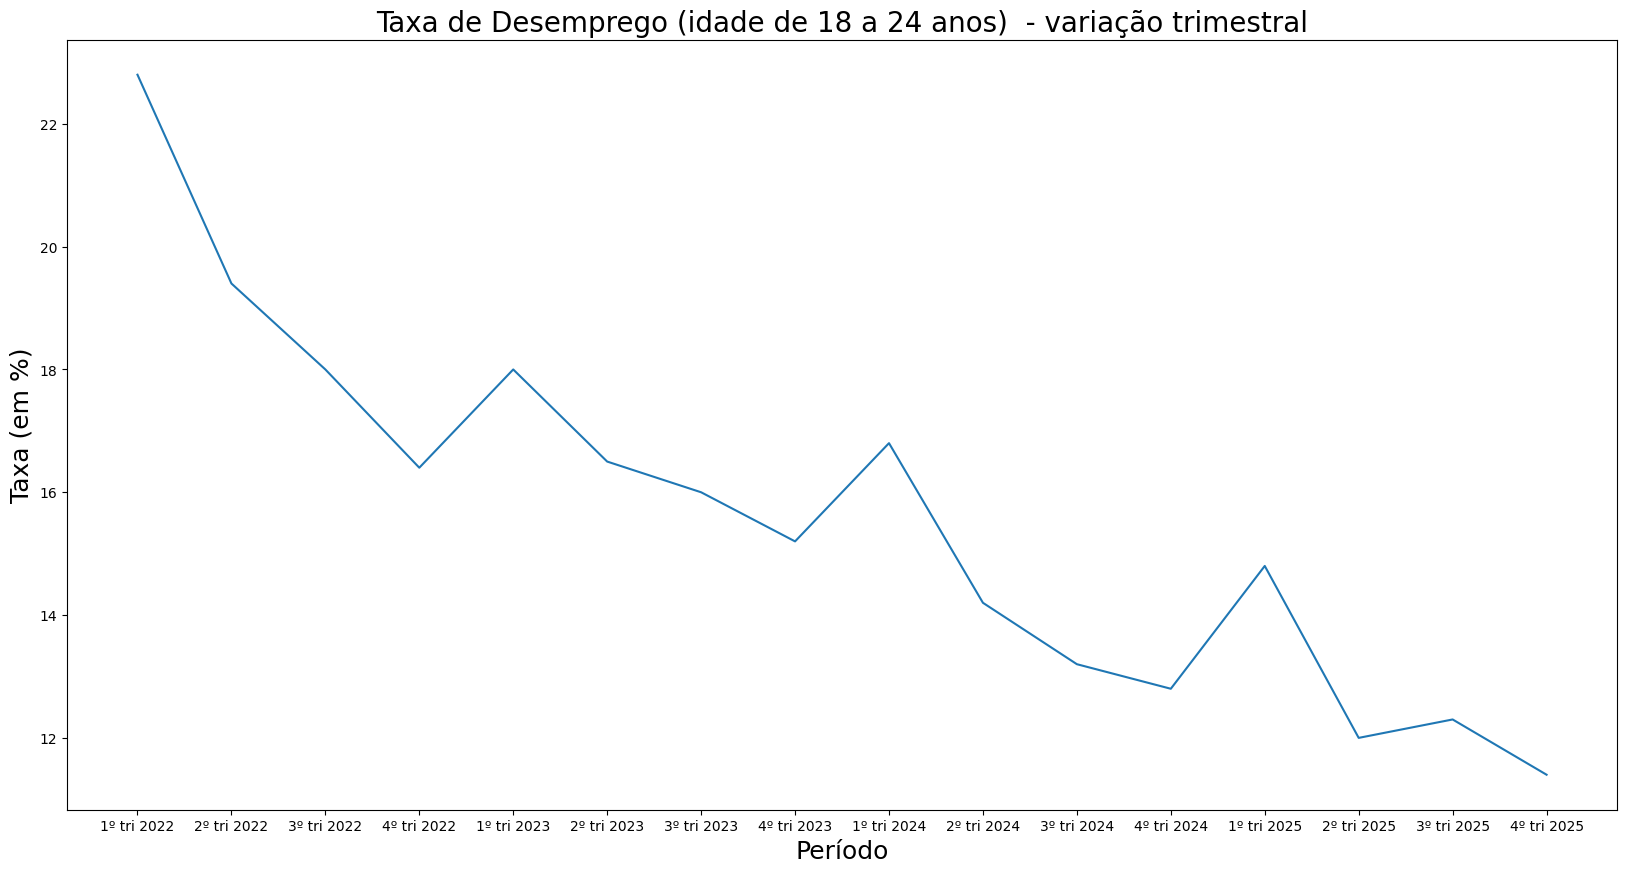

In [84]:
#gráfico de linha (dados com intervalo de tempo)
#usaremos o arquivo obtido do site do IBGE
dados=pd.read_excel('desemprego.xlsx')
fig,ax=plt.subplots(figsize=(20,10))
sns.lineplot(x=dados['periodo'],y=dados['taxa percentual'])
ax.set_xlabel("Período", size=18)
ax.set_ylabel("Taxa (em %)",size=18)
ax.set_title("Taxa de Desemprego (idade de 18 a 24 anos)  - variação trimestral",size=20)
plt.show()

**Histograma com seaborn e com matplotlib**

Note que o histograma também pode ser feito a partir da tabela de frequência obtida com dados em intervalos de classe. Para isso importe as bibliotecas (matplotlib e seaborn) naquele notebook e utilize as funções.





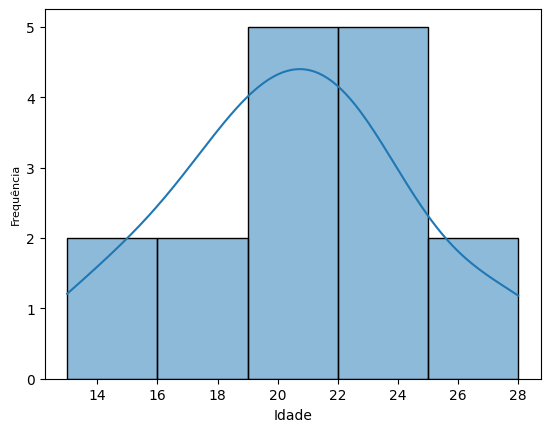

In [85]:
sns.histplot(data=df,x="Idade",kde=True)
plt.ylabel("Frequência",size=8)
plt.show()

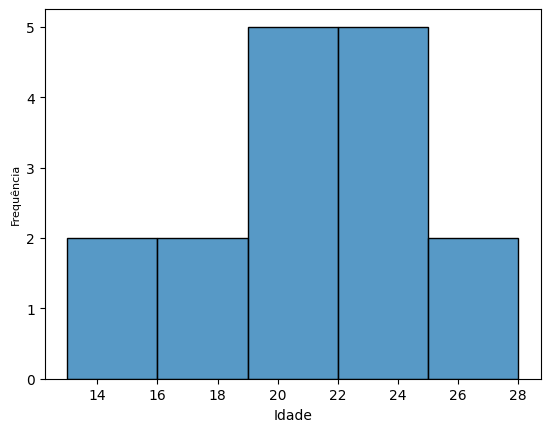

In [86]:
#excluindo a curva que aparece no gráfico
sns.histplot(data=df,x="Idade",kde=False)
plt.ylabel("Frequência",size=8)
plt.show()

PARA FAZERMOS UM HISTOGRAMA É INTERESSANTE SABERMOS OS VALORES MÍNIMO E MÁXIMO DO CONJUNTO DE DADOS.

In [87]:
valormin=min(df.Idade)
valormax=max(df.Idade)
valormin,valormax


(13, 28)

**NO GRÁFICO MONTADO A SEGUIR TOME CUIDADO COM OS EXTREMOS DO INTERVALO. LEMBRE QUE EM PYTHON O INTERVALO À DIREITA É ABERTO (COMO VIMOS NOS COMANDOS DE LISTAS). PORTANTO,  SE TEMOS O VALOR MÁXIMO DOS DADOS COMO SENDO 28, ENTÃO TEMOS QUE ESTENDER O INTERVALO PARA O PRÓXIMO INTEIRO.**

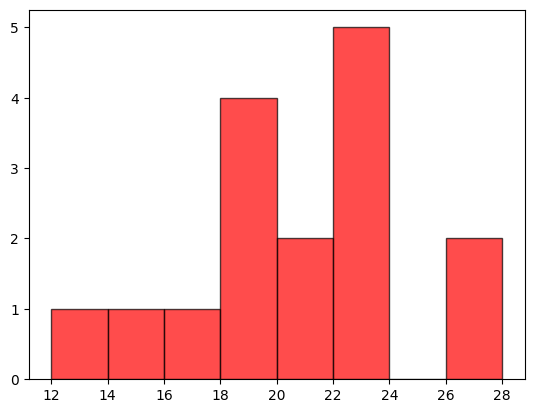

In [88]:
#Construindo o histograma da variável Idade restringindo o tamanho de cada classe. NO EXEMPLO TAMANHO DA CLASSE = 2
classes=range(12,29,2)
plt.hist(df.Idade,bins=classes,rwidth=1, color='red', alpha=0.7, edgecolor='black')
plt.show()

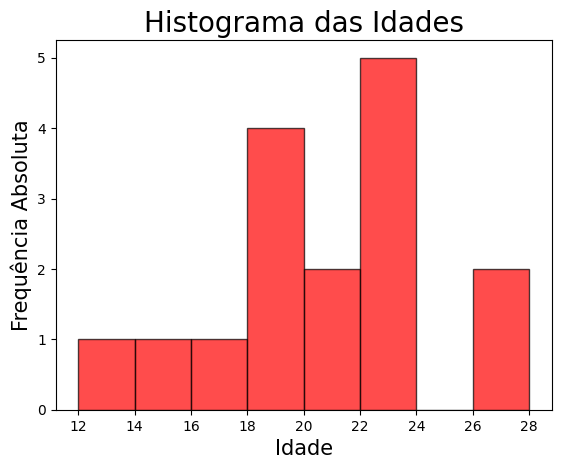

In [89]:
#Incluindo as legendas dos eixos e o título do gráfico
plt.title('Histograma das Idades', fontsize=20)
plt.xlabel('Idade', fontsize=15)
plt.ylabel('Frequência Absoluta', fontsize=15)
plt.tick_params(labelsize=10)
plt.hist(df.Idade,bins=classes,rwidth=1, color='red', alpha=0.7, edgecolor='black')
plt.show()

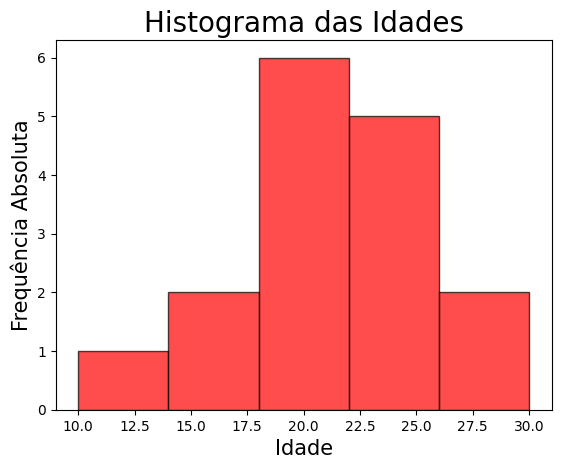

In [90]:
#Construindo o histograma da variável Idade informando os limites inferiores e superiores de cada classe. Lembre de respeitar o valor máximo!!
classes=[10,14,18,22,26,30]
plt.hist(df.Idade,bins=classes,rwidth=1, color='red', alpha=0.7, edgecolor='black')
#título e legendas
plt.title('Histograma das Idades', fontsize=20)
plt.xlabel('Idade', fontsize=15)
plt.ylabel('Frequência Absoluta', fontsize=15)
plt.tick_params(labelsize=10)
plt.show()

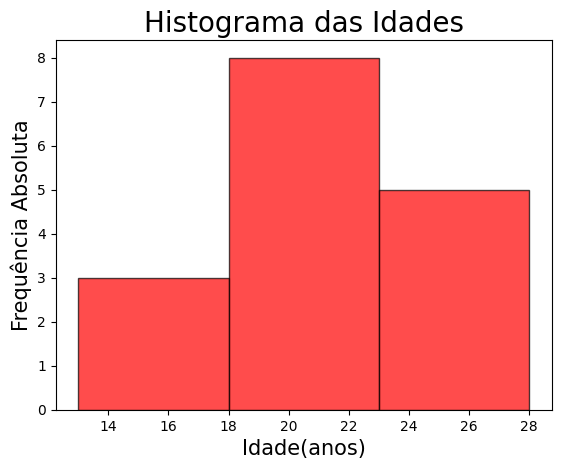

In [91]:
#Construindo o histograma da variável Idade informando a quantidade de classes pretendida. NO EXEMPLO BINS=3.
plt.hist(df.Idade,bins=3,rwidth=1, color='red', alpha=0.7, edgecolor='black')
#título e legendas
plt.title('Histograma das Idades', fontsize=20)
plt.xlabel('Idade(anos)', fontsize=15)
plt.ylabel('Frequência Absoluta', fontsize=15)
plt.tick_params(labelsize=10)
plt.show()


**Medidas de Tendência Central**


*   Média, Moda e Mediana




In [92]:
#cálculo da Média, indicando Dataframe e a coluna em questão, no exemplo df.Idade
df.Idade.mean()

np.float64(20.5)

In [93]:
# cálculo da moda. Mesmas indicações
df.Idade.mode()

,Idade
0,19
1,23


In [94]:
#cálculo da mediana.
df.Idade.median()

20.5

In [95]:
#para dado qualitativo, calculamos a moda
df.Sexo.mode()

,Sexo
0,fem
1,masc


In [96]:
df.Escolaridade.mode()

,Escolaridade
0,médio
1,superior


In [97]:
#para os dados do IBGE

In [98]:
#média para a coluna taxa
dados['taxa percentual'].mean()

np.float64(15.6125)

In [99]:
# com 2 casas decimais
dados['taxa percentual'].mean().round(2)

np.float64(15.61)

In [100]:
#moda para coluna taxa
dados['taxa percentual'].mode()

,taxa percentual
0,18.0


In [101]:
#cálculo da mediana para coluna taxa
dados['taxa percentual'].median()

15.6

In [102]:
#comando describe mostra várias medidas das variáveis quantitativas, incluindo média e mediana.
df.Idade.describe().round(2)


,Idade
count,16.00
mean,20.50
std,4.02
min,13.00
25%,18.75
50%,20.50
75%,23.00
max,28.00


In [103]:
dados['taxa percentual'].describe().round(2)

,taxa percentual
count,16.00
mean,15.61
std,3.04
min,11.40
25%,13.10
50%,15.60
75%,17.10
max,22.80
